In [53]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

# Import data from LES

In [ ]:
binning = True  # Set to True for binning test, False for matching test

if binning:
    print("Running binning test...")
    num_bins = 100  # Set the desired number of bins for the test (only active if binning = "True")
    test_identifier = num_bins  # Set the test identifier for saving files
else:
    test_identifier = 'vdiff_600_hdiff_60'  # Set the test identifier for saving files

test_id = '110T218L25'
path = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/epm-input.nc"
with xr.open_dataset(path) as ds:
    original_epm_bypass_dataset = ds.load()

# Import LLES data to match
LES_data = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/{test_id}.csv")
LES_initial_mass_per_m = LES_data['Ice_mass'].values[0]
LES_initial_number_per_m = LES_data['Ice_number'].values[0]
LES_initial_area = LES_data['Area_m2'].values[0]
LES_initial_effective_radius = LES_data['Effective_radius_um'].values[0]

if test_id.startswith("110"):
    LES_initial_PSD = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_crystal_radius/110T205L25/110T205L25_5min.csv")
else:
    LES_initial_PSD = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_crystal_radius/130T225L25/130T225L25_5min.csv")

print(f"Initial LES quantities for {test_id}:\n")
print(f"Initial Ice Mass per m: {LES_initial_mass_per_m:.4f} kg/m")
print(f"Initial Ice Number per m: {LES_initial_number_per_m:.4f} #/m")
print(f"Initial Area: {LES_initial_area:.4f} m²")
print(f"Initial Effective Radius: {LES_initial_effective_radius:.4f} μm")

Running binning test...
Initial LES quantities for 110T218L25:

Initial Ice Mass per m: 0.0045 kg/m
Initial Ice Number per m: 947000000000.0000 #/m
Initial Area: 785.3982 m²
Initial Effective Radius: 1.2000 μm


In [55]:
original_epm_bypass_dataset

<xarray.Dataset>
Dimensions:       (so4_r: 44, so4_r_e: 45, ice_r: 38, ice_r_e: 39)
Coordinates:
  * so4_r         (so4_r) float64 1.108e-10 1.348e-10 ... 4.154e-07 5.053e-07
  * so4_r_e       (so4_r_e) float64 1e-10 1.216e-10 ... 4.559e-07 5.546e-07
  * ice_r         (ice_r) float64 5.541e-08 6.74e-08 ... 6.41e-05 7.798e-05
  * ice_r_e       (ice_r_e) float64 5e-08 6.082e-08 ... 7.036e-05 8.559e-05
Data variables:
    finalTemp     float64 218.2
    iceRadius     float64 1.282e-06
    iceDensity    float64 210.7
    sootDensity   float64 0.0
    H2O_mol       float64 2.114
    SO4g_mol      float64 6.819e-16
    SO4l_mol      float64 0.0
    area          float64 785.4
    bypassArea    float64 1.28
    coreExitTemp  float64 615.0
    so4_pdf       (so4_r) float64 5.246e-15 6.007e-14 ... 2.504e-97 1.873e-102
    ice_pdf       (ice_r) float64 0.0 0.0 0.0 1.079 1.464 ... 0.0 0.0 0.0 0.0

## Binning Test

In [56]:
if binning == True:
# For binning test: update the bin edges to match the 15-bin configuration
    # The bin edges start at 50nm and the bin centers increase by a factor of 2^1/3 (doubling mass) each time
    original_bin_edges = original_epm_bypass_dataset['ice_r_e'].values
    original_bin_centers = original_epm_bypass_dataset['ice_r'].values
    original_num_bins = len(original_bin_centers)

    new_bin_centers = np.zeros(num_bins)
    new_bin_widths = np.zeros(num_bins)
    new_bin_edges = np.zeros(num_bins + 1)

    new_bin_edges[0] = original_bin_edges[0]  # Start at 50nm
    new_bin_edges[-1] = original_bin_edges[-1]  # End at 1mm
    new_bin_centers[0] = original_bin_centers[0]  # Start at 50nm

    K0 = 1.21644  # the original factor by which the radius increases for each subsequent bin center
    K = K0**((original_num_bins - 1)/(num_bins -1))  # Calculate the radius ratio to maintain the same range with fewer bins
    
    for i in range(1, num_bins):
        new_bin_centers[i] = new_bin_centers[i-1] * K
        new_bin_edges[i] = new_bin_edges[0] * K**(i)  # Calculate the new bin edges based on the new bin centers

    # Make a copy of the EPM dataset to edit and save at the end of the script
    new_epm_bypass_dataset = original_epm_bypass_dataset.copy()

    # for binning test: update the bin edges to match the 15-bin configuration
    # Delete the existing ice_r_e and ice_r variables and replace with the new bin edges and centers
    new_epm_bypass_dataset = new_epm_bypass_dataset.drop_vars(['ice_r_e', 'ice_r', 'ice_pdf'])

    # Assign new coordinates/dimensions directly — does NOT affect other variables
    new_epm_bypass_dataset = new_epm_bypass_dataset.assign_coords({
        'ice_r': new_bin_centers,
        'ice_r_e': new_bin_edges,
    })

    # Create new variable for ice_pdf with the correct dimensions and values
    new_epm_bypass_dataset['ice_pdf'] = (('ice_r'), np.zeros(num_bins))  # Create a new ice_pdf variable with the correct number of bins
    # Create new r_ice_e and r_ice coordinates with the new bin edges and centers
    new_epm_bypass_dataset['ice_r_e'] = (('ice_r_e'), new_bin_edges)
    new_epm_bypass_dataset['ice_r'] = (('ice_r'), new_bin_centers)

else:
    # Make a copy of the EPM dataset to edit and save at the end of the script
    new_epm_bypass_dataset = original_epm_bypass_dataset.copy()


In [57]:
new_epm_bypass_dataset

<xarray.Dataset>
Dimensions:       (so4_r: 44, so4_r_e: 45, ice_r: 100, ice_r_e: 101)
Coordinates:
  * so4_r         (so4_r) float64 1.108e-10 1.348e-10 ... 4.154e-07 5.053e-07
  * so4_r_e       (so4_r_e) float64 1e-10 1.216e-10 ... 4.559e-07 5.546e-07
  * ice_r         (ice_r) float64 5.541e-08 5.962e-08 ... 7.247e-05 7.797e-05
  * ice_r_e       (ice_r_e) float64 5e-08 5.38e-08 ... 7.036e-05 8.559e-05
Data variables:
    finalTemp     float64 218.2
    iceRadius     float64 1.282e-06
    iceDensity    float64 210.7
    sootDensity   float64 0.0
    H2O_mol       float64 2.114
    SO4g_mol      float64 6.819e-16
    SO4l_mol      float64 0.0
    area          float64 785.4
    bypassArea    float64 1.28
    coreExitTemp  float64 615.0
    so4_pdf       (so4_r) float64 5.246e-15 6.007e-14 ... 2.504e-97 1.873e-102
    ice_pdf       (ice_r) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [58]:
### Set the EPM ice radius to the Sauter mean radius of the LES PSD
LLES_sauter_mean = LRTlib.calculate_sauter_mean(LES_initial_PSD.iloc[:,0].values, LES_initial_PSD.iloc[:,1].values)
print(f"LLES sauter mean radius: {LLES_sauter_mean:.2f} µm")
new_epm_bypass_dataset['iceRadius'] = LLES_sauter_mean * 1e-6  # Convert to meters

### Convert the LES PSD datapoints onto the EPM bin system
# Bin the LLES data using the specified bin edges
bin_edges = new_epm_bypass_dataset['ice_r_e'].values * 1e6  # Convert to µm
bin_indices = np.digitize(LES_initial_PSD.iloc[:,0], bin_edges) - 1

# Prepare arrays to store mean radius and mean value per bin
mean_radii = []
mean_values = []
bin_width = []
unscaled_total_ice_number_LES = 0

for i in range(len(bin_edges) - 1):
    mask = bin_indices == i
    if np.any(mask):
        bin_width.append(np.log(bin_edges[i+1]) - np.log(bin_edges[i]))
        mean_radii.append(new_epm_bypass_dataset['ice_r'].values[i] * 1e6)  # Mean radius is the center of the bin
        mean_values.append(LES_initial_PSD.iloc[:,1][mask].mean())
    else:
        bin_width.append(np.log(bin_edges[i+1]) - np.log(bin_edges[i]))
        mean_radii.append(new_epm_bypass_dataset['ice_r'].values[i] * 1e6)  # Mean radius is the center of the bin
        mean_values.append(0.0)

### Scale the LES PSD to match the total number of ice particles in the LES dataset
ice_pdf = np.array(mean_values)      # [#/cm³] per ln(r)
ice_r_e = new_epm_bypass_dataset['ice_r_e'].values  # [m]
log_bin_widths = np.log(ice_r_e[1:] / ice_r_e[:-1])
area = new_epm_bypass_dataset['area'].values

# Calculate total particles
moment_0 = np.sum(ice_pdf * log_bin_widths)
total_particles = moment_0 * area * 1e6 # #/m
total_req_particles = LES_initial_number_per_m
print(area)
num_scaling = total_req_particles / (moment_0 * area * 1e6)
print(f"number scaling factor: {num_scaling}")
num_engines = 2
new_epm_bypass_dataset['ice_pdf'].values = num_scaling * ice_pdf * (1/num_engines)

ice_pdf = new_epm_bypass_dataset['ice_pdf'].values      # [#/cm³] per ln(r)
print(f"Total particles after scaling: {np.sum(ice_pdf * np.log(ice_r_e[1:] / ice_r_e[:-1])) * area * 1e6:.3e} [#/m]")

### Calculate total ice mass from the scaled PSD
### Ice mass calculation
ice_r = new_epm_bypass_dataset['ice_r'].values # [m]

# 3rd moment
moment_3 = np.sum(ice_pdf * (ice_r**3) * log_bin_widths)

# Convert to volume concentration [m³/cm³]
volume_factor = (4.0/3.0) * np.pi
volume_concentration = volume_factor * moment_3  # [m³/cm³]
total_volume_per_m = volume_concentration * area * 1e6  # [m³/m]

RHO_ICE = 917  # [kg/m³]
total_mass = total_volume_per_m * RHO_ICE  # [kg/m]
two_engine_total_mass = 2 * total_mass
print(f"Total ice mass for two engines: {two_engine_total_mass:.6f} [kg/m]")

LLES sauter mean radius: 1.28 µm
785.3981633974482
number scaling factor: 1.2109612083566204e-10
Total particles after scaling: 4.735e+11 [#/m]
Total ice mass for two engines: 0.005221 [kg/m]


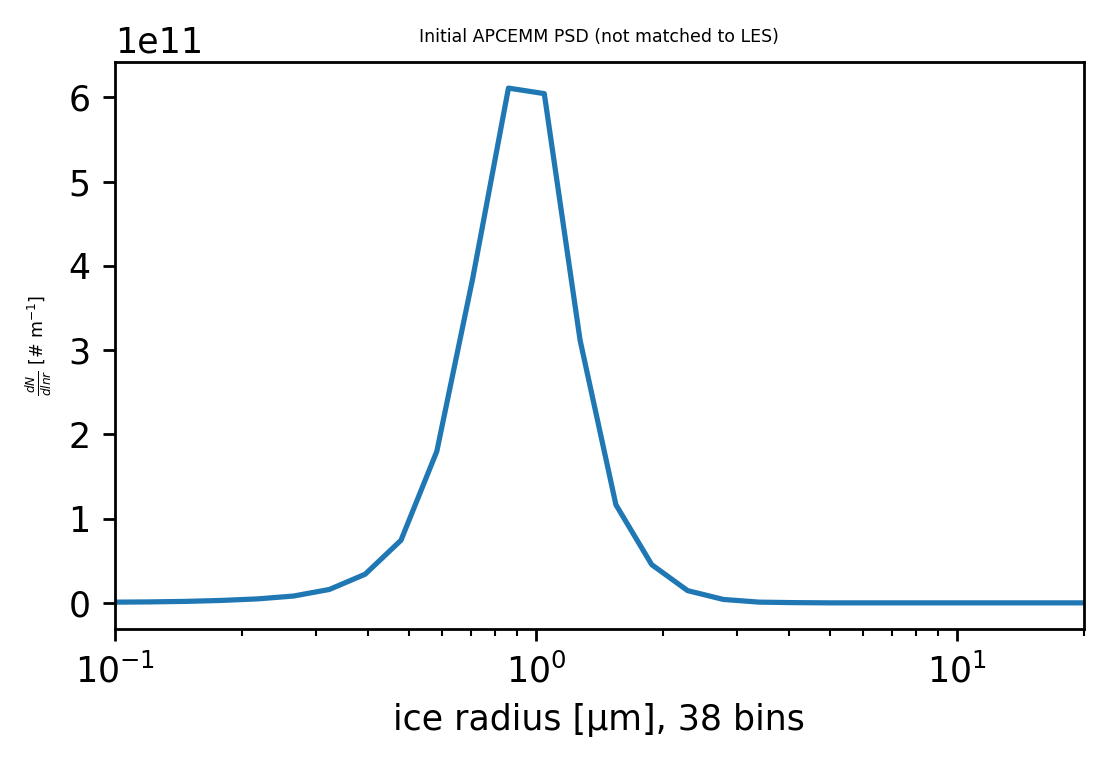

In [59]:
# Plot the number of ice particles per bin
plt.figure(figsize=(5,3), dpi=250)
plt.plot(original_epm_bypass_dataset['ice_r'].values * 1e6, original_epm_bypass_dataset['ice_pdf'].values * 1e6 * original_epm_bypass_dataset['area'].values)
plt.xscale('log')
plt.xlabel('ice radius [µm], 38 bins')
plt.ylabel(r'$\frac{dN}{dlnr}$ [# m$^{-1}$]', fontsize=5)
plt.xlim(0.1, 20)
plt.title("Initial APCEMM PSD (not matched to LES)", fontsize=5)
plt.show()

# Re-bin and scale LES PSD onto EPM grid

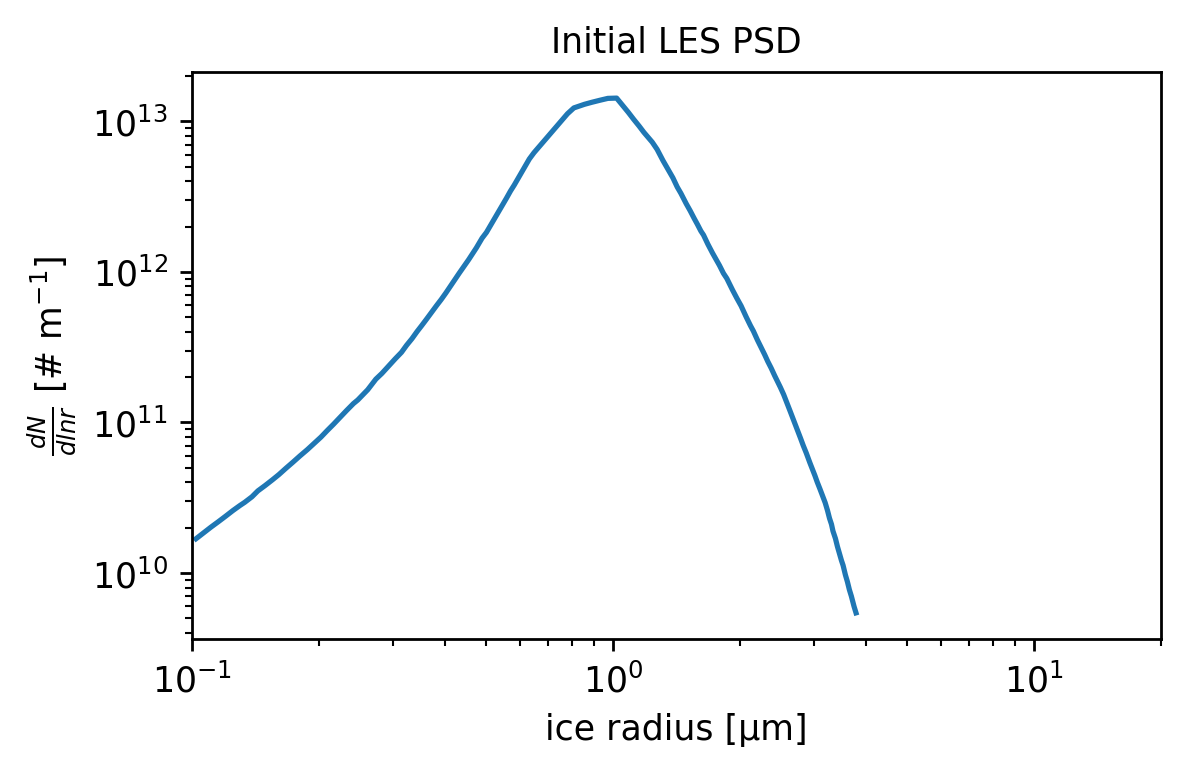

In [60]:
# Plot the unscaled LLES data with column 1 as x and column 2 as y
plt.figure(figsize=(5,3), dpi=250)
plt.plot(LES_initial_PSD.iloc[:,0], LES_initial_PSD.iloc[:,1])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('ice radius [µm]')
plt.ylabel(r'$\frac{dN}{dlnr}$ [# m$^{-1}$]', fontsize=10)
plt.xlim(0.1, 20)
plt.title("Initial LES PSD", fontsize=10)
plt.show()

# Check saved values

In [61]:
print(test_id)
saved_total_ice_num = 2 * np.sum(new_epm_bypass_dataset['ice_pdf'].values * np.log(new_epm_bypass_dataset['ice_r_e'].values[1:] / new_epm_bypass_dataset['ice_r_e'].values[:-1]) * new_epm_bypass_dataset['area'].values * 1e6)
print(f"New APCEMM EPM bypass total ice number, both engines [# m^-1]: {saved_total_ice_num:.3e}")
print(f"LES initial total ice number, both engines [# m^-1]: {LES_initial_number_per_m:.3e}")

print(f"New APCEMM EPM bypass initial ice mass per m: {two_engine_total_mass:.4f} kg/m")
print(f"LES initial ice mass per m: {LES_initial_mass_per_m:.4f} kg/m")

print(f"New APCEMM EPM bypass initial effective radius: {new_epm_bypass_dataset['iceRadius'].values} µm")
print(f"LES initial effective radius: {LRTlib.calculate_sauter_mean(LES_initial_PSD.iloc[:,0].values, LES_initial_PSD.iloc[:,1].values)} µm")

110T218L25
New APCEMM EPM bypass total ice number, both engines [# m^-1]: 9.470e+11
LES initial total ice number, both engines [# m^-1]: 9.470e+11
New APCEMM EPM bypass initial ice mass per m: 0.0052 kg/m
LES initial ice mass per m: 0.0045 kg/m
New APCEMM EPM bypass initial effective radius: 1.2819013890259444e-06 µm
LES initial effective radius: 1.2819013890259445 µm


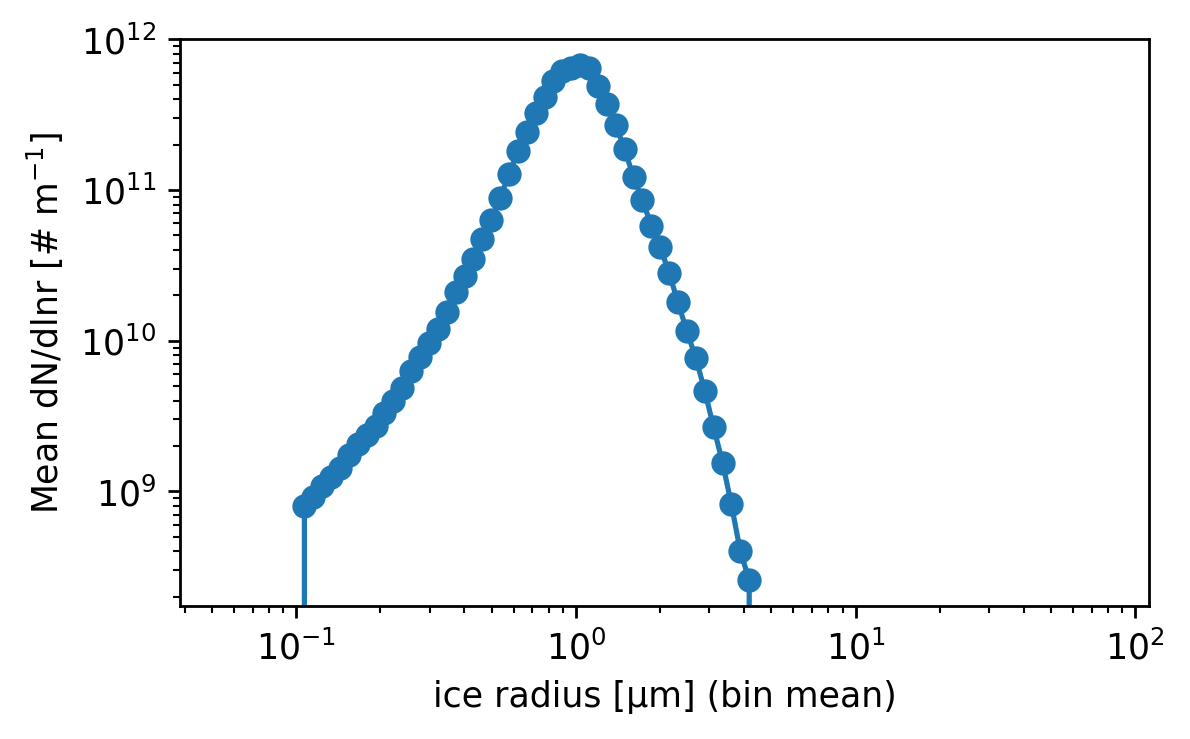

In [62]:
# Plot the binned means
plt.figure(figsize=(5,3), dpi=250)
plt.plot(new_epm_bypass_dataset['ice_r'].values * 1e6, new_epm_bypass_dataset['ice_pdf'].values * 1e6 * new_epm_bypass_dataset['area'].values, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('ice radius [µm] (bin mean)')
plt.ylabel('Mean dN/dlnr [# m$^{-1}$]')
# plt.xlim(0.1, 20)
plt.show()

## Save the scaled LES distribution to the epm-output.nc file

In [63]:
new_epm_bypass_dataset

<xarray.Dataset>
Dimensions:       (so4_r: 44, so4_r_e: 45, ice_r: 100, ice_r_e: 101)
Coordinates:
  * so4_r         (so4_r) float64 1.108e-10 1.348e-10 ... 4.154e-07 5.053e-07
  * so4_r_e       (so4_r_e) float64 1e-10 1.216e-10 ... 4.559e-07 5.546e-07
  * ice_r         (ice_r) float64 5.541e-08 5.962e-08 ... 7.247e-05 7.797e-05
  * ice_r_e       (ice_r_e) float64 5e-08 5.38e-08 ... 7.036e-05 8.559e-05
Data variables:
    finalTemp     float64 218.2
    iceRadius     float64 1.282e-06
    iceDensity    float64 210.7
    sootDensity   float64 0.0
    H2O_mol       float64 2.114
    SO4g_mol      float64 6.819e-16
    SO4l_mol      float64 0.0
    area          float64 785.4
    bypassArea    float64 1.28
    coreExitTemp  float64 615.0
    so4_pdf       (so4_r) float64 5.246e-15 6.007e-14 ... 2.504e-97 1.873e-102
    ice_pdf       (ice_r) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [64]:
# # Save the changes to the original_epm_bypass_dataset
if binning == True:
    new_epm_bypass_dataset.to_netcdf((f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/epm-input-{num_bins}-bins.nc"))
else:
    new_epm_bypass_dataset.to_netcdf((f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/epm-input-{test_identifier}.nc"))

In [65]:
# load in and compare the epm-input.nc and epm-input-38-bins.nc 
# check if the bin edges and centers are the same in both files (they should be since the default numbe rof bins is 38)
base_dir = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}"
path_default = f"{base_dir}/epm-input.nc"
path_38 = f"{base_dir}/epm-input-38-bins.nc"

with xr.open_dataset(path_default) as ds_default, xr.open_dataset(path_38) as ds_38:
    centers_default = ds_default["ice_r"].values
    centers_38 = ds_38["ice_r"].values
    edges_default = ds_default["ice_r_e"].values
    edges_38 = ds_38["ice_r_e"].values

print(f"ice_r size: default={centers_default.size}, 38-bins={centers_38.size}")
print(f"ice_r_e size: default={edges_default.size}, 38-bins={edges_38.size}")

same_centers_exact = np.array_equal(centers_default, centers_38)
same_edges_exact = np.array_equal(edges_default, edges_38)

same_centers_close = np.allclose(centers_default, centers_38, rtol=0, atol=0)
same_edges_close = np.allclose(edges_default, edges_38, rtol=0, atol=0)

print(f"Centers identical (exact): {same_centers_exact}")
print(f"Edges identical (exact):   {same_edges_exact}")
print(f"Centers identical (allclose): {same_centers_close}")
print(f"Edges identical (allclose):   {same_edges_close}")

if not same_centers_exact:
    print("Max |center diff|:", np.max(np.abs(centers_default - centers_38))*1e6, "µm")
if not same_edges_exact:
    print("Max |edge diff|:", np.max(np.abs(edges_default - edges_38))*1e6, "µm")

ice_r size: default=38, 38-bins=38
ice_r_e size: default=39, 38-bins=39
Centers identical (exact): False
Edges identical (exact):   False
Centers identical (allclose): False
Edges identical (allclose):   False
Max |center diff|: 0.0009465923461602277 µm
Max |edge diff|: 0.0008541554706776753 µm
